## 1.0 Парсинг файла с данными по ежемесячным ценам угля.

In [82]:
import pandas as pd
file_path = 'CMO-Historical-Data-Monthly.xlsx'
df_prices = pd.read_excel(file_path, sheet_name='Monthly Prices', header=5)
# По заголовкам из файла: Australian Coal в колонке F, South African Coal в колонке G
df_coal = df_prices.iloc[:, [0, 5, 6]].copy()  # A, F, G
df_coal.columns = ['Date', 'Australian_Coal', 'South_African_Coal']
df_coal['Date'] = pd.to_datetime(df_coal['Date'], format='%YM%m')
df_coal = df_coal.dropna()

for col in ['Australian_Coal', 'South_African_Coal']:
    df_coal[col] = pd.to_numeric(df_coal[col], errors='coerce')
df_coal = df_coal.dropna()
df_coal.reset_index(drop=True, inplace=True)
print(df_coal.head(10))
print(f"\nДиапазон данных: {df_coal['Date'].min()} — {df_coal['Date'].max()}")
print(f"Всего строк: {len(df_coal)}")


        Date  Australian_Coal  South_African_Coal
0 1984-01-01            29.25               29.34
1 1984-02-01            29.25               29.34
2 1984-03-01            29.25               29.34
3 1984-04-01            29.25               29.34
4 1984-05-01            29.25               29.34
5 1984-06-01            31.75               34.31
6 1984-07-01            31.75               35.80
7 1984-08-01            31.75               35.80
8 1984-09-01            31.75               35.80
9 1984-10-01            31.75               35.80

Диапазон данных: 1984-01-01 00:00:00 — 2026-05-01 00:00:00
Всего строк: 509


## 1.1 Парсинг файла с данными по погрузке угля (Росстат)

In [83]:
file_path = "Pogruzka-04-2026.xlsx"  
years = list(range(2005, 2027))
data = []

for year in years:
    try:
        df = pd.read_excel(file_path, sheet_name=str(year), header=None)
    except Exception as e:
        print(f"Лист {year} не найден: {e}")
        continue
    
    # Ищем строку с "каменный уголь"
    mask = df[0].astype(str).str.contains("каменный уголь", na=False)
    if not mask.any():
        print(f"В листе {year} не найдена строка с 'каменный уголь'")
        continue
    
    row_idx = mask[mask].index[0]
    # Месяцы со столбца B (индекс 1) по M (индекс 12)
    monthly_values = df.iloc[row_idx, 1:13].values
    
    # Записываем каждый месяц
    for month_num, value in enumerate(monthly_values, start=1):
        if pd.notna(value):
            date = pd.Timestamp(year=year, month=month_num, day=1)
            data.append({"date": date, "coal_loading": value})


df_gruz = pd.DataFrame(data)
df_gruz = df_gruz.sort_values("date").reset_index(drop=True)

print(df_gruz.head(20))
print(f"\nВсего записей: {len(df_gruz)}")
print(f"\nПериод: с {df_gruz['date'].min()} по {df_gruz['date'].max()}")


         date  coal_loading
0  2005-01-01       25391.0
1  2005-02-01       22853.0
2  2005-03-01       24552.0
3  2005-04-01       21681.0
4  2005-05-01       21661.0
5  2005-06-01       20481.0
6  2005-07-01       20024.0
7  2005-08-01       21981.0
8  2005-09-01       22948.0
9  2005-10-01       25410.0
10 2005-11-01       25980.0
11 2005-12-01       25286.0
12 2006-01-01       24102.0
13 2006-02-01       23507.0
14 2006-03-01       25817.0
15 2006-04-01       23601.0
16 2006-05-01       22918.0
17 2006-06-01       21753.0
18 2006-07-01       21818.0
19 2006-08-01       22823.0

Всего записей: 256

Период: с 2005-01-01 00:00:00 по 2026-04-01 00:00:00


## 1.3 Парсинг данных по курсу рубля к доллару, изначально подневные - берем среднее за месяц.

In [84]:
# Загрузка данных из файла
file_path = "RC_F01_01_2005_T06_06_2026.xlsx"
df = pd.read_excel(file_path, sheet_name="RC")
df.columns = ["nominal", "data", "curs", "cdx"]
df["data"] = pd.to_datetime(df["data"])
df["ano_mes"] = df["data"].dt.to_period("M")

media_mensal = df.groupby("ano_mes")["curs"].mean().reset_index()
media_mensal["date"] = media_mensal["ano_mes"].dt.start_time
df_kurs = media_mensal[["date", "curs"]].copy()
df_kurs.rename(columns={"curs": "kurs"}, inplace=True)
print(df_kurs)

C:\Users\User\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


          date       kurs
0   2005-01-01  28.009087
1   2005-02-01  27.995395
2   2005-03-01  27.626423
3   2005-04-01  27.810355
4   2005-05-01  27.951378
..         ...        ...
253 2026-02-01  76.927800
254 2026-03-01  80.503740
255 2026-04-01  76.889773
256 2026-05-01  72.811205
257 2026-06-01  73.044200

[258 rows x 2 columns]


## 1.4 Обьединение данных

In [85]:
df_coal = df_coal.rename(columns={'Date': 'date'})
df_gruz = df_gruz.rename(columns={'date': 'date'})  # уже 'date'
df_kurs = df_kurs.rename(columns={'date': 'date'})  # уже 'date'
df_coal['date'] = pd.to_datetime(df_coal['date'])
df_gruz['date'] = pd.to_datetime(df_gruz['date'])
df_kurs['date'] = pd.to_datetime(df_kurs['date'])
df_merged = pd.merge(df_coal, df_gruz, on='date', how='inner')
df_merged = pd.merge(df_merged, df_kurs, on='date', how='inner')
df_merged = df_merged.sort_values('date').reset_index(drop=True)
final_columns = ['date']
for col in ['Australian_Coal', 'South_African_Coal', 'coal_loading', 'kurs']:
    if col in df_merged.columns:
        final_columns.append(col)
df_merged = df_merged[final_columns]
print(f"\nИтоговый датасет без пропусков:")
print(df_merged.head(10))

df_merged.to_csv("coal_forecast_1.csv", index=False, encoding="utf-8")


Итоговый датасет без пропусков:
        date  Australian_Coal  South_African_Coal  coal_loading       kurs
0 2005-01-01            53.05               51.42       25391.0  28.009087
1 2005-02-01            49.90               46.63       22853.0  27.995395
2 2005-03-01            50.93               45.30       24552.0  27.626423
3 2005-04-01            51.25               46.25       21681.0  27.810355
4 2005-05-01            51.31               45.88       21661.0  27.951378
5 2005-06-01            51.00               49.13       20481.0  28.497867
6 2005-07-01            50.90               51.31       20024.0  28.694432
7 2005-08-01            49.13               49.50       21981.0  28.479809
8 2005-09-01            45.25               46.63       22948.0  28.380014
9 2005-10-01            42.46               43.25       25410.0  28.563133


## 2.1 Визуализация переменных

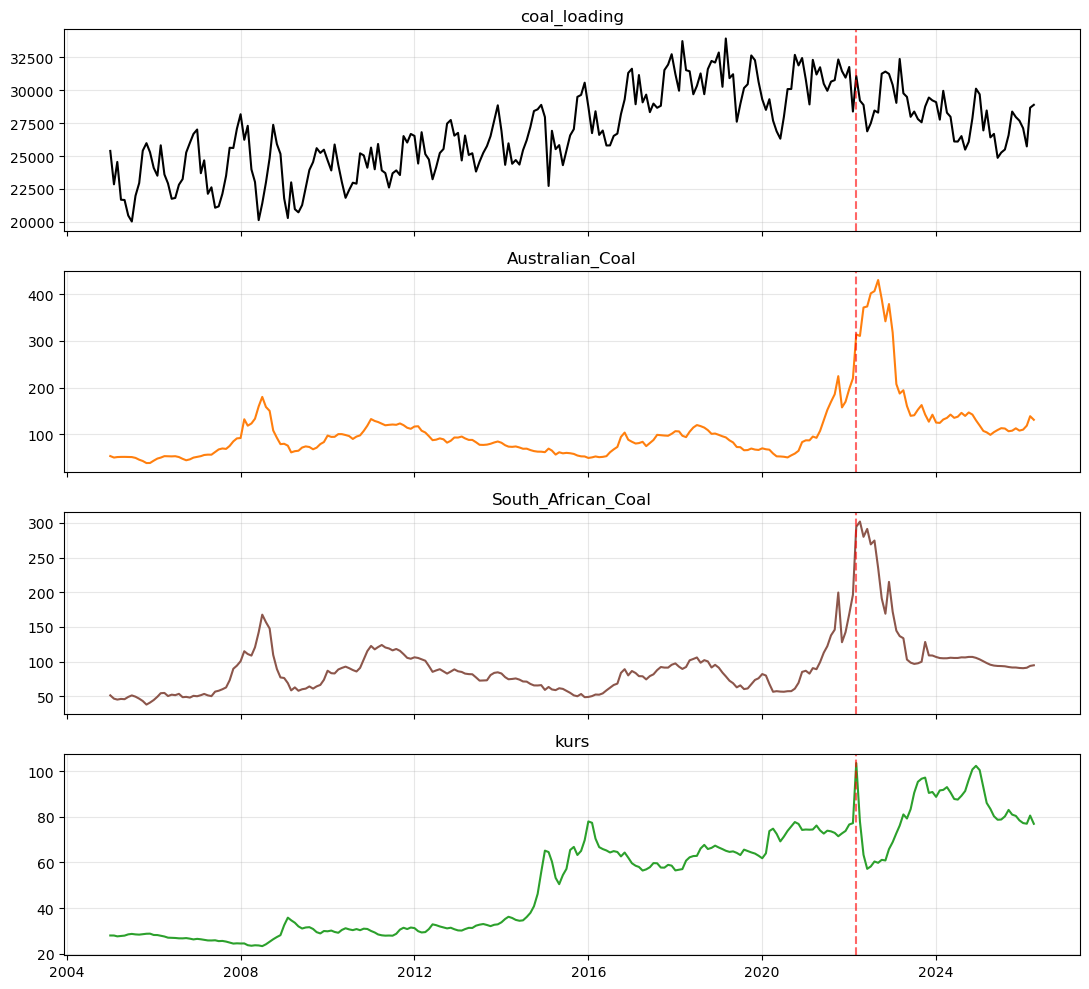

In [86]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv("coal_forecast_1.csv", parse_dates=["date"]).set_index("date")

cols   = ["coal_loading", "Australian_Coal", "South_African_Coal", "kurs"]
colors = ["black", "tab:orange", "tab:brown", "tab:green"]

fig, ax = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for a, c, col in zip(ax, cols, colors):
    a.plot(df.index, df[c], color=col); a.set_title(c); a.grid(alpha=.3)
    a.axvline(pd.Timestamp("2022-03-01"), color="red", ls="--", alpha=.6)
plt.tight_layout();plt.show()

## 2.2 Корреляционная матрица

                    Australian_Coal  South_African_Coal  coal_loading  kurs
Australian_Coal                1.00                0.94          0.28  0.30
South_African_Coal             0.94                1.00          0.27  0.26
coal_loading                   0.28                0.27          1.00  0.66
kurs                           0.30                0.26          0.66  1.00
                    Australian_Coal  South_African_Coal  coal_loading  kurs
Australian_Coal                1.00                0.97          0.32  0.34
South_African_Coal             0.97                1.00          0.32  0.28
coal_loading                   0.32                0.32          1.00  0.70
kurs                           0.34                0.28          0.70  1.00


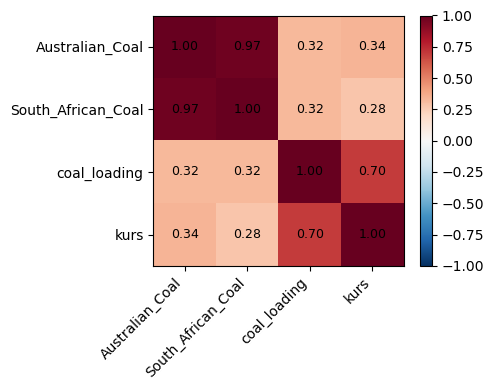

In [87]:
print(df.corr().round(2))
print(np.log(df).corr().round(2))

c = np.log(df).corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(c))); ax.set_xticklabels(c.columns, rotation=45, ha="right")
ax.set_yticks(range(len(c))); ax.set_yticklabels(c.columns)
for i in range(len(c)):
    for j in range(len(c)):
        ax.text(j, i, f"{c.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im); plt.tight_layout(); plt.show()

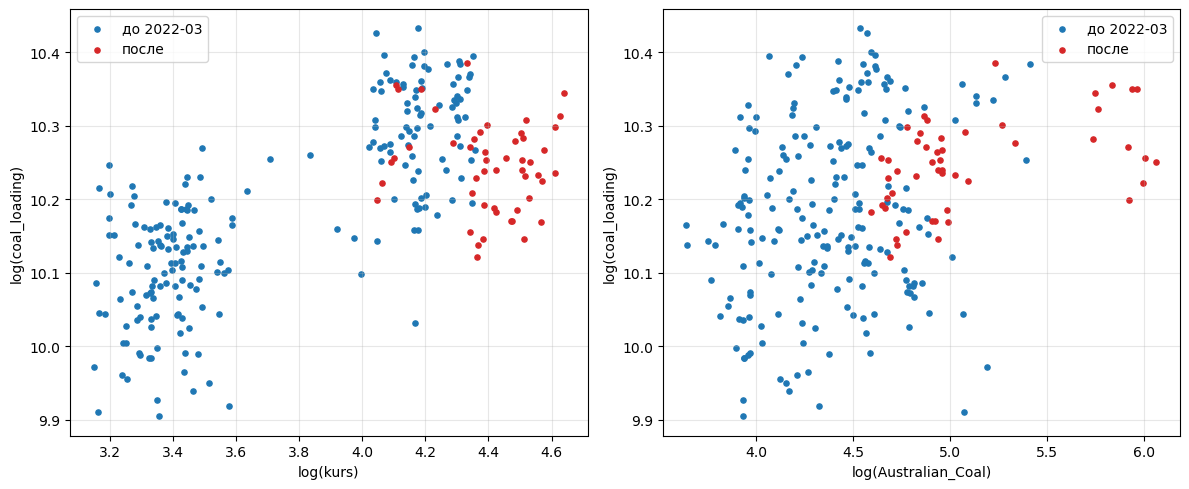

In [88]:
ld  = np.log(df)
pre = df.index < "2022-03-01"

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, x in zip(ax, ["kurs", "Australian_Coal"]):
    a.scatter(ld[x][pre],  ld["coal_loading"][pre],  s=14, c="tab:blue", label="до 2022-03")
    a.scatter(ld[x][~pre], ld["coal_loading"][~pre], s=14, c="tab:red",  label="после")
    a.set_xlabel(f"log({x})"); a.set_ylabel("log(coal_loading)"); a.grid(alpha=.3); a.legend()
plt.tight_layout(); plt.show()

## 3.1 Оценка простой регрессии МНК с сезональностью

In [127]:
import statsmodels.formula.api as smf
d = np.log(df[["coal_loading", "Australian_Coal", "kurs"]]).rename(
    columns={"coal_loading": "lcoal", "Australian_Coal": "lprice", "kurs": "lfx"})
d["month"] = d.index.month
train, test = d.iloc[:-test_n], d.iloc[-test_n:]
m = smf.ols("lcoal ~ lprice + lfx + C(month)", data=train).fit()

pred = np.exp(m.predict(test))       
actual = np.exp(test["lcoal"])
resid  = actual - pred

mape = (resid.abs() / actual).mean() * 100
bias = (resid / actual).mean() * 100    # знак систематической ошибки

print(f"MAPE = {mape:.1f}%")
print(f"Bias = {bias:+.1f}%   ({'переоценивает' if bias < 0 else 'недооценивает'} факт)")

MAPE = 13.5%
Bias = -13.5%   (переоценивает факт)


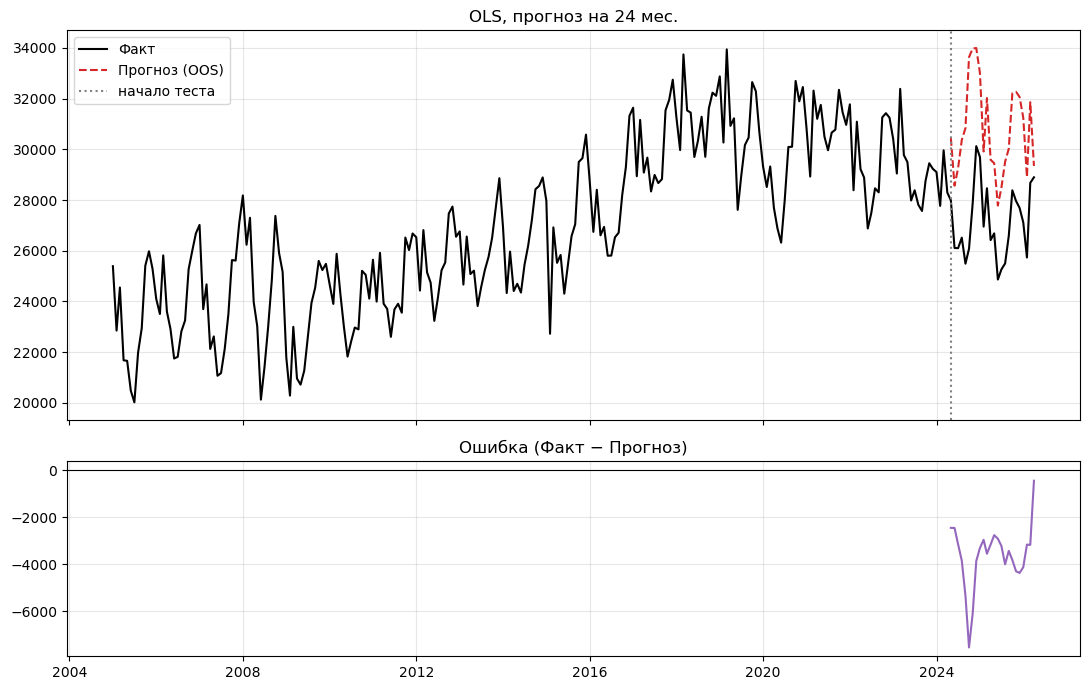

In [128]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(np.exp(d["lcoal"]), color="black", label="Факт")
ax[0].plot(pred, color="tab:red", ls="--", label="Прогноз (OOS)")
ax[0].axvline(test.index[0], color="gray", ls=":", label="начало теста")
ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_title(f"OLS, прогноз на {test_n} мес.")
ax[1].plot(resid.index, resid, color="tab:purple"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_title("Ошибка (Факт − Прогноз)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [133]:
def interpret_adfuller(series, name="Временной ряд"):
    from statsmodels.tsa.stattools import adfuller
    
    result = adfuller(series)
    p_value = result[1]
    stat = result[0]
    critical_values = result[4]
    
    print(f"=== РЕЗУЛЬТАТЫ ADF-ТЕСТА ДЛЯ: {name.upper()} ===")
    print(f"ADF статистика: {stat:.4f}")
    print(f"p-value:        {p_value:.4f}")
    print("-" * 35)
    
    # Логика интерпретации
    if p_value < 0.05:
        conclusion = "Ряд СТАЦИОНАРЕН (отвергаем нулевую гипотезу о наличии единичного корня)"
    else:
        conclusion = "Ряд НЕСТАЦИОНАРЕН (не можем отвергнуть гипотезу о единичном корне)"
        
    print(f"Вердикт: {conclusion}")
    print("-" * 35)
    print("Критические значения:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.4f}")

# Использование:
interpret_adfuller(test['lcoal'], name="Погрузка угля (log)")

=== РЕЗУЛЬТАТЫ ADF-ТЕСТА ДЛЯ: ПОГРУЗКА УГЛЯ (LOG) ===
ADF статистика: -2.5641
p-value:        0.1007
-----------------------------------
Вердикт: Ряд НЕСТАЦИОНАРЕН (не можем отвергнуть гипотезу о единичном корне)
-----------------------------------
Критические значения:
   1%: -3.7529
   5%: -2.9985
   10%: -2.6390


In [148]:
d['d_lcoal'] = d['lcoal'].diff()
d_stable = d.dropna()
interpret_adfuller(d_stable['d_lcoal'], name="Погрузка угля (log)")

=== РЕЗУЛЬТАТЫ ADF-ТЕСТА ДЛЯ: ПОГРУЗКА УГЛЯ (LOG) ===
ADF статистика: -5.8613
p-value:        0.0000
-----------------------------------
Вердикт: Ряд СТАЦИОНАРЕН (отвергаем нулевую гипотезу о наличии единичного корня)
-----------------------------------
Критические значения:
   1%: -3.4576
   5%: -2.8735
   10%: -2.5731


In [93]:
start = len(d) - 24
rows = []
for i in range(start, len(d)):
    m = smf.ols("lcoal ~ lprice + lfx + C(month)", data=d.iloc[:i]).fit()
    p = float(np.exp(m.predict(d.iloc[[i]]).iloc[0]))
    rows.append((d.index[i], np.exp(d["lcoal"].iloc[i]), p))

roll = pd.DataFrame(rows, columns=["date", "actual", "pred"]).set_index("date")
roll["err"] = roll.actual - roll.pred
print(f'Rolling MAPE = {(roll.err.abs()/roll.actual).mean()*100:.1f}%')
print(f'Rolling Bias = {(roll.err/roll.actual).mean()*100:+.1f}%')

Rolling MAPE = 11.9%
Rolling Bias = -11.8%


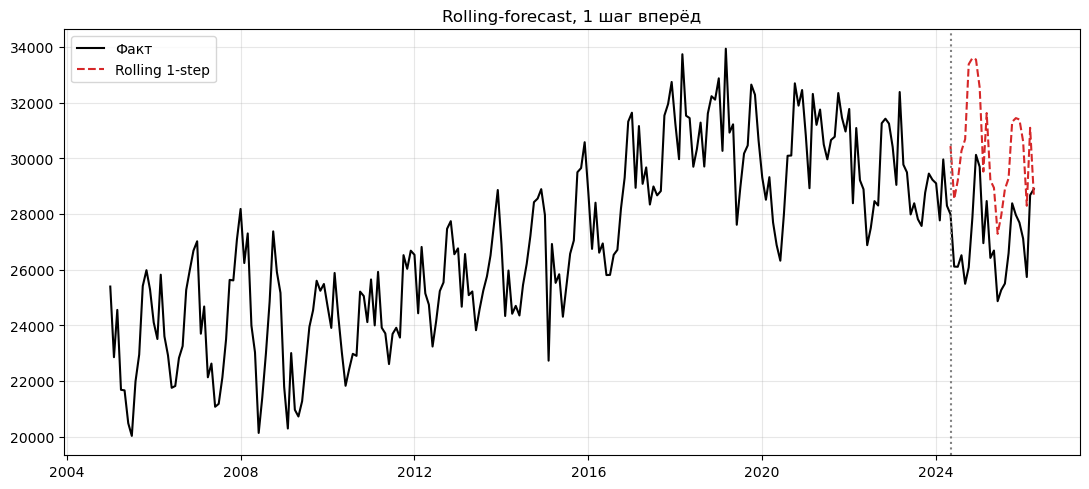

In [94]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(np.exp(d["lcoal"]), color="black", label="Факт")
ax.plot(roll.pred, color="tab:red", ls="--", label="Rolling 1-step")
ax.axvline(roll.index[0], color="gray", ls=":")
ax.legend(); ax.grid(alpha=.3); ax.set_title("Rolling-forecast, 1 шаг вперёд")
plt.tight_layout(); plt.show()

## 3.2 DW TEST сильно меньше 1, есть автокорреляция, добавляем 1 лаг целевой переменной

In [95]:
d["lcoal_lag1"] = d["lcoal"].shift(1)          # один раз, до цикла

start = len(d) - 24
rows = []
for i in range(start, len(d)):
    train = d.iloc[:i].dropna()                # dropna из-за лага в первой строке
    m = smf.ols("lcoal ~ lcoal_lag1 + lprice + lfx + C(month)", data=train).fit()
    p = float(np.exp(m.predict(d.iloc[[i]]).iloc[0]))
    rows.append((d.index[i], np.exp(d["lcoal"].iloc[i]), p))

roll = pd.DataFrame(rows, columns=["date", "actual", "pred"]).set_index("date")
roll["err"] = roll.actual - roll.pred
print(f'MAPE = {(roll.err.abs()/roll.actual).mean()*100:.1f}%')
print(f'Bias = {(roll.err/roll.actual).mean()*100:+.1f}%')

MAPE = 3.0%
Bias = -1.0%


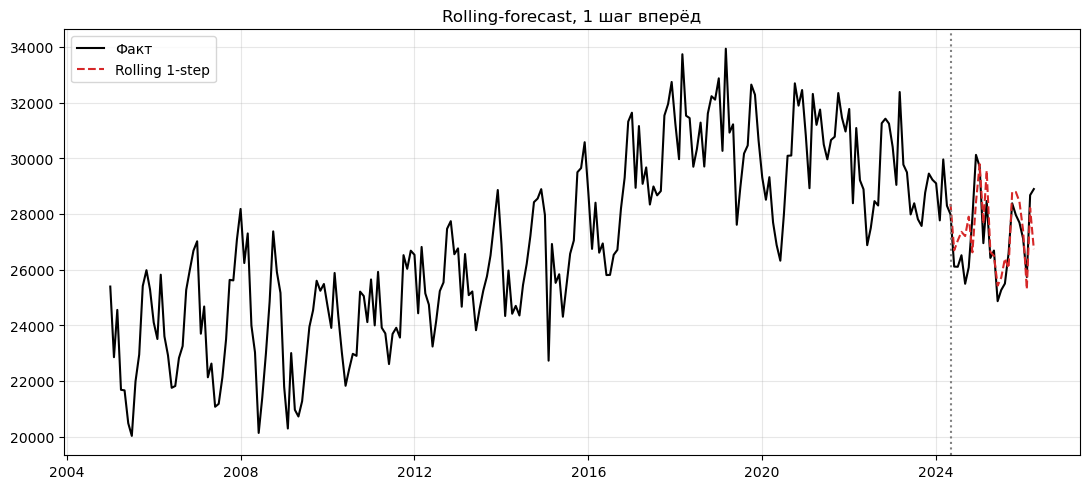

In [96]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(np.exp(d["lcoal"]), color="black", label="Факт")
ax.plot(roll.pred, color="tab:red", ls="--", label="Rolling 1-step")
ax.axvline(roll.index[0], color="gray", ls=":")
ax.legend(); ax.grid(alpha=.3); ax.set_title("Rolling-forecast, 1 шаг вперёд")
plt.tight_layout(); plt.show()

In [97]:
m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lcoal   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     246.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          3.03e-133
Time:                        18:36:13   Log-Likelihood:                 530.25
No. Observations:                 254   AIC:                            -1030.
Df Residuals:                     239   BIC:                            -977.4
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.8599      0.275      3.131      0.002       0.319       1.401
C(month)[T.2]     -0.0594      0.009     -6.285      0.000      -0.078      -0.041
C(month)[T.3]      0.0961      0.010      9.749      0.000       0.077       0.116
C(month)[T.4]     -0.0564      0.010     -5.901      0.000      -0.075      -0.038
C(month)[T.5]      0.0076      0.010      0.774      0.440      -0.012       0.027
C(month)[T.6]     -0.0439      0.010     -4.452      0.000      -0.063      -0.024
C(month)[T.7]      0.0320      0.010      3.073      0.002       0.011       0.052
C(month)[T.8]      0.0429      0.010      4.221      0.000       0.023       0.063
C(month)[T.9]      0.0241      0.010      2.436      0.016       0.005       0.044
C(month)[T.10]     0.0842      0.010      8.596      0.000       0.065       0.104
C(month)[T.11]     0.0245      0.010      2.567      0.011       0.006       0.043
C(month)[T.12]     0.0268      0.010      2.813      0.005       0.008       0.046
lcoal_lag1         0.9087      0.029     31.502      0.000       0.852       0.966
lprice          3.768e-05      0.004      0.008      0.993      -0.009       0.009
lfx                0.0145      0.007      2.197      0.029       0.002       0.028
==============================================================================
Omnibus:                       30.608   Durbin-Watson:                   1.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.951
Skew:                          -0.630   Prob(JB):                     9.59e-14
Kurtosis:                       5.019   Cond. No.                     1.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 3.3 Коэффициент при лаге примерно 1, что нехорошо, так как в реальности данные появляются с запаздыванием и планирование долгосрочное

In [98]:
train = d[d.index < "2024-01-01"].dropna()
test  = d[d.index >= "2024-01-01"]
m = smf.ols("lcoal ~ lcoal_lag1 + lprice + lfx + C(month)", data=train).fit()

last_lag = train["lcoal"].iloc[-1]      # последний реальный факт
preds = []
for dt, row in test.iterrows():
    x = row.copy()
    x["lcoal_lag1"] = last_lag          # подставляем прошлый прогноз (на 1-м шаге — факт)
    yhat = m.predict(pd.DataFrame([x])).iloc[0]
    preds.append(yhat)
    last_lag = yhat                     # ключевая строка: прогноз становится лагом

roll = pd.DataFrame({"actual": np.exp(test["lcoal"]),
                     "pred":   np.exp(preds)}, index=test.index)
roll["err"] = roll.actual - roll.pred
print(f'MAPE = {(roll.err.abs()/roll.actual).mean()*100:.1f}%')
print(f'Bias = {(roll.err/roll.actual).mean()*100:+.1f}%')

MAPE = 9.8%
Bias = -9.5%


## 3.4 Присутствует структурный сдвиг после 2022, также прогноз делаем на квартал, поэтому меняем rolling backtest, т.е. модель будет видеть каждые 3 месяца реальные данные.   

In [100]:
d["post2022"] = (d.index >= "2022-03-01").astype(int)

def backtest(formula, frozen=False, H=3, test_n=24):
    rows = []
    for i in range(len(d)-test_n, len(d)-H+1):
        m = smf.ols(formula, data=d.iloc[:i].dropna()).fit()
        hist = d["lcoal"].values.copy()
        fx0, price0 = d["lfx"].iloc[i-1], d["lprice"].iloc[i-1]   # заморозка на origin-1
        for h in range(H):
            j = i + h; x = d.iloc[j].copy()
            if frozen: x["lfx"] = fx0; x["lprice"] = price0       # вместо реального будущего
            x["lcoal_lag1"] = hist[j-1]
            yh = float(m.predict(pd.DataFrame([x])).iloc[0])
            rows.append((d.index[j], h+1, np.exp(d["lcoal"].iloc[j]), np.exp(yh))); hist[j] = yh
    r = pd.DataFrame(rows, columns=["date","h","actual","pred"]); r["err"] = r.actual-r.pred
    return r


f = "lcoal ~ lcoal_lag1 + lprice + lfx + C(month) + post2022"
r = backtest(f)
print(f'квартал: MAPE={(r.err.abs()/r.actual).mean()*100:.1f}%  Bias={(r.err/r.actual).mean()*100:+.1f}%')
for h in (1,2,3):
    s = r[r.h==h]; print(f'  h={h}: MAPE={(s.err.abs()/s.actual).mean()*100:.1f}%  Bias={(s.err/s.actual).mean()*100:+.1f}%')

квартал: MAPE=3.6%  Bias=-1.3%
  h=1: MAPE=2.4%  Bias=-0.8%
  h=2: MAPE=3.8%  Bias=-1.5%
  h=3: MAPE=4.7%  Bias=-1.6%


Дальнейшие дешевые улчушения a la AR(2) и лаги других переменных MAPE не двигают, поэтому нужны другие данные.

## 3.5 Курс и цены в оценке изначальной модели предполагался известным, однако в реальности это не так, поэтому в реальности при оценке будет накапливаться еще и ошибка предсказания курса и цены. В данной секции проверим будут ли сильные изменения, если мы заморозим курс и цену, сильно ли измениться MAPE

In [101]:
print(f"MAPE with frozen prices and exchange rate :{backtest(f, frozen=True).pipe(lambda r: (r.err.abs()/r.actual).mean()*100)}")

MAPE with frozen prices and exchange rate :3.7189352407701306


Таким образом, разница в MAPE даже с фиксированным курсом и ценами угля незначительная. 

## 3.6 Ряд получается похожим на случайное блуждание, т.к. очень высокие коэффициент у лага. Значит осталось проверить на единичный корень.

In [102]:
from statsmodels.tsa.stattools import adfuller
print(adfuller(d["lcoal"].dropna())[1])   # p-value

0.45212233144372516


ADF не отвергает единичный корень...

## 3.7 Проверим стационарность в первых разностях и проведем тесты на коинтеграцию

In [103]:
import pandas as pd, numpy as np
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
df = pd.read_csv("coal_forecast_1.csv", parse_dates=["date"]).set_index("date")
d = np.log(df[["coal_loading", "Australian_Coal", "kurs"]]).rename(
    columns={"coal_loading": "lcoal", "Australian_Coal": "lprice", "kurs": "lfx"})
d["month"] = d.index.month
d["dcoal"]  = d["lcoal"].diff()
d["dfx"]    = d["lfx"].diff()
d["dprice"] = d["lprice"].diff()
d["dcoal_lag1"] = d["dcoal"].shift(1)

def backtest_diff(formula, tgt_lags, frozen=False, H=3, test_n=24):
    rows = []
    for i in range(len(d) - test_n, len(d) - H + 1):
        m = smf.ols(formula, data=d.iloc[:i].dropna()).fit()
        dh = d["dcoal"].values.copy()          # история приростов
        level = d["lcoal"].iloc[i - 1]         # реальный последний уровень
        for h in range(H):
            j = i + h
            x = d.iloc[j].copy()
            if frozen:
                x["dfx"] = 0.0; x["dprice"] = 0.0
            for k in tgt_lags:
                x[f"dcoal_lag{k}"] = dh[j - k]
            dyh = float(m.predict(pd.DataFrame([x])).iloc[0])
            level = level + dyh                 # собираем уровень из приростов
            rows.append((d.index[j], h + 1, np.exp(d["lcoal"].iloc[j]), np.exp(level)))
            dh[j] = dyh
    r = pd.DataFrame(rows, columns=["date", "h", "actual", "pred"])
    r["err"] = r.actual - r.pred
    return r


f = "dcoal ~ dcoal_lag1 + dfx + dprice + C(month)"
for label, fr in [("РАЗНОСТИ, реальные X", False), ("РАЗНОСТИ, заморозка X", True)]:
    r = backtest_diff(f, [1], frozen=fr)
    mape = (r.err.abs() / r.actual).mean() * 100
    bias = (r.err / r.actual).mean() * 100
    print(f"{label}: MAPE={mape:.1f}%  Bias={bias:+.1f}%")
print("  (LEVEL-модель давала: MAPE 3.6% / Bias -1.3% при реальных X)\n")

mm = smf.ols(f, data=d.dropna()).fit()
print("коэффициенты diff-модели:")
for v in ["dcoal_lag1", "dfx", "dprice"]:
    print(f"  {v:11s}= {mm.params[v]:+.3f}  (p={mm.pvalues[v]:.2g})")
print(f"  R^2={mm.rsquared:.3f}\n")


# --- коинтеграция ---
print("=== Engle-Granger (H0: НЕТ коинтеграции) ===")
for a, b in [("lcoal", "lfx"), ("lcoal", "lprice")]:
    p = coint(d[a], d[b])[1]
    print(f"  {a} ~ {b}: p={p:.3f}  -> {'ЕСТЬ' if p < 0.05 else 'НЕТ'}")

print("\n=== Johansen (lcoal, lfx): trace vs крит.95% ===")
jo = coint_johansen(d[["lcoal", "lfx"]].dropna(), det_order=0, k_ar_diff=2)
for rnk in range(len(jo.lr1)):
    stat, cv95 = jo.lr1[rnk], jo.cvt[rnk, 1]
    print(f"  r<={rnk}: trace={stat:.2f}  crit95={cv95:.2f}  "
          f"-> {'отвергаем' if stat > cv95 else 'не отвергаем'}")

print("\n=== Engle-Granger ТОЛЬКО до слома (по фев-2022) ===")
pre = d[d.index < "2022-03-01"]
print(f"  lcoal ~ lfx (до 2022): p={coint(pre['lcoal'], pre['lfx'])[1]:.3f}")

РАЗНОСТИ, реальные X: MAPE=4.1%  Bias=-1.1%
РАЗНОСТИ, заморозка X: MAPE=3.9%  Bias=-0.9%
  (LEVEL-модель давала: MAPE 3.6% / Bias -1.3% при реальных X)

коэффициенты diff-модели:
  dcoal_lag1 = +0.051  (p=0.43)
  dfx        = -0.060  (p=0.16)
  dprice     = -0.045  (p=0.039)
  R^2=0.725

=== Engle-Granger (H0: НЕТ коинтеграции) ===
  lcoal ~ lfx: p=0.200  -> НЕТ
  lcoal ~ lprice: p=0.787  -> НЕТ

=== Johansen (lcoal, lfx): trace vs крит.95% ===
  r<=0: trace=38.70  crit95=15.49  -> отвергаем
  r<=1: trace=1.24  crit95=3.84  -> не отвергаем

=== Engle-Granger ТОЛЬКО до слома (по фев-2022) ===
  lcoal ~ lfx (до 2022): p=0.037


Видно, что до 2022 года коинтеграция работала, но после - нет. Возможно стоит включить пропускную способность восточного полигона. 
На всей выборке коинтеграции нет вообще. 

In [104]:
mm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  dcoal   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     45.03
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           6.86e-59
Time:                        18:37:11   Log-Likelihood:                 525.50
No. Observations:                 254   AIC:                            -1021.
Df Residuals:                     239   BIC:                            -967.9
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0192      0.007     -2.769      0.006      -0.033      -0.006
C(month)[T.2]     -0.0558      0.010     -5.634      0.000      -0.075      -0.036
C(month)[T.3]      0.1087      0.011      9.797      0.000       0.087       0.131
C(month)[T.4]     -0.0591      0.011     -5.410      0.000      -0.081      -0.038
C(month)[T.5]      0.0172      0.011      1.536      0.126      -0.005       0.039
C(month)[T.6]     -0.0361      0.010     -3.690      0.000      -0.055      -0.017
C(month)[T.7]      0.0491      0.011      4.646      0.000       0.028       0.070
C(month)[T.8]      0.0534      0.010      5.451      0.000       0.034       0.073
C(month)[T.9]      0.0300      0.010      3.037      0.003       0.011       0.049
C(month)[T.10]     0.0894      0.010      9.164      0.000       0.070       0.109
C(month)[T.11]     0.0203      0.011      1.921      0.056      -0.001       0.041
C(month)[T.12]     0.0282      0.010      2.896      0.004       0.009       0.047
dcoal_lag1         0.0511      0.065      0.789      0.431      -0.076       0.179
dfx               -0.0600      0.043     -1.412      0.159      -0.144       0.024
dprice            -0.0452      0.022     -2.073      0.039      -0.088      -0.002
==============================================================================
Omnibus:                       14.831   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               27.999
Skew:                          -0.294   Prob(JB):                     8.32e-07
Kurtosis:                       4.517   Cond. No.                         34.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 4.1 Виден структурный сдвиг после 2022 года, теперь цена угля не дает эффекта на погрузку, что странно, поэтому вместо мировой цены будем использовать netback с ЦЦИ, при этом данных стало меньше, наблюдения только с 2023-04

In [105]:
netback = {
 '2023-04':3740,'2023-05':2799.3,'2023-06':1576.4,'2023-07':2287.1,'2023-08':2500.4,
 '2023-09':3235,'2023-10':3891.4,'2023-11':2914.9,'2023-12':2498.3,
 '2024-02':2145.5,'2024-03':1833.6,'2024-04':1086.4,'2024-05':1675.5,'2024-06':1491.9,
 '2024-07':1511.1,'2024-08':1568.3,'2024-09':1873.5,'2024-10':2616.2,'2024-11':2870.4,'2024-12':2301.1,
 '2025-02':613.2,'2025-03':-294.6,'2025-04':-331.3,'2025-05':-345.6,'2025-06':-157.2,'2025-07':-77.9,
 '2025-08':1122.9,'2025-09':1371,'2025-10':1765.3,'2025-11':2310.8,'2025-12':1292.7,
 '2026-02':1499.7,'2026-03':1790.3,'2026-04':1663.4,'2026-05':1931}

nb = pd.Series(netback); nb.index = pd.to_datetime(nb.index)
nb = nb.reindex(pd.date_range('2023-04-01', '2026-05-01', freq='MS')).ffill()   # январи = декабрь

df = pd.read_csv("coal_forecast_1.csv", parse_dates=["date"]).set_index("date")
m = df.join(nb.rename("netback"), how="inner").dropna()

In [106]:
print("Корреляции с погрузкой (уровни):")
for c in ["netback", "Australian_Coal", "kurs"]:
    print(f"  {c:16s}: {m['coal_loading'].corr(m[c]):+.2f}")

print()
for c in ["netback", "Australian_Coal"]:
    r = smf.ols(f"coal_loading ~ {c}", data=m).fit()
    print(f"  OLS coal ~ {c:16s}: R2={r.rsquared:.2f}  p={r.pvalues[c]:.3g}")

Корреляции с погрузкой (уровни):
  netback         : +0.55
  Australian_Coal : +0.35
  kurs            : +0.31

  OLS coal ~ netback         : R2=0.31  p=0.000392
  OLS coal ~ Australian_Coal : R2=0.12  p=0.0343



погрузка при netback<0 (мар-июл25): 26340  vs  вне окна: 27908  (-5.6%)


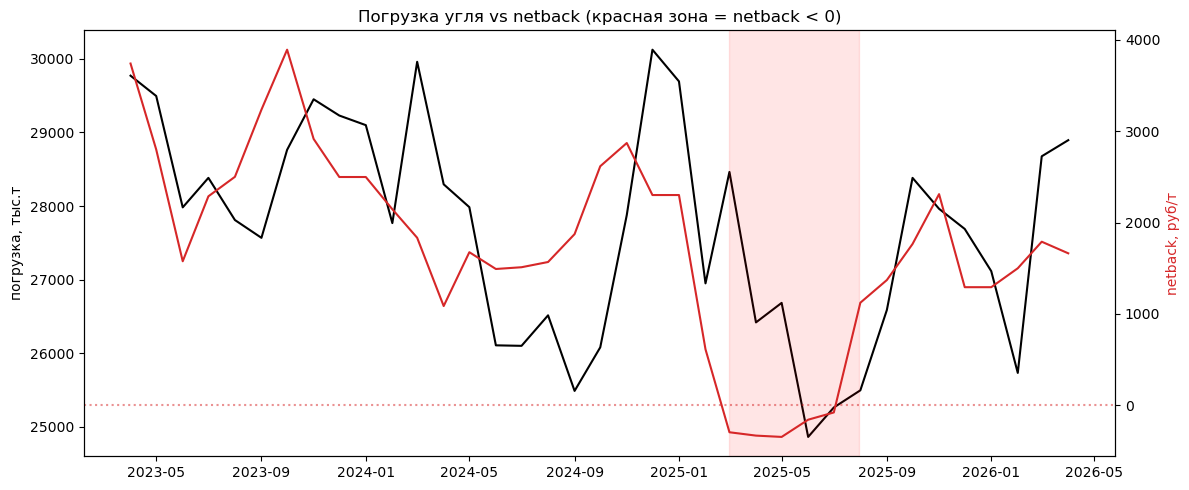

In [107]:
import matplotlib.pyplot as plt

# провал 2025: netback в минусе март-июль
neg = m.loc["2025-03":"2025-07", "coal_loading"].mean()
rest = m.loc[m.index.difference(m.loc["2025-03":"2025-07"].index), "coal_loading"].mean()
print(f"\nпогрузка при netback<0 (мар-июл25): {neg:.0f}  vs  вне окна: {rest:.0f}  ({neg/rest-1:+.1%})")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(m.index, m["coal_loading"], color="black", label="Погрузка")
ax1.set_ylabel("погрузка, тыс.т")
ax2 = ax1.twinx()
ax2.plot(m.index, m["netback"], color="tab:red", label="Netback")
ax2.set_ylabel("netback, руб/т", color="tab:red")
ax2.axhline(0, color="tab:red", ls=":", alpha=.5)
ax2.axvspan(pd.Timestamp("2025-03-01"), pd.Timestamp("2025-07-31"), color="red", alpha=.1)
ax1.set_title("Погрузка угля vs netback (красная зона = netback < 0)")
plt.tight_layout(); plt.show()

Dummy Fourier Used

In [108]:
# netback есть только с 2023-04 -> оценка на коротком общем окне.
# Спец упрощена под 36 точек: Фурье вместо C(month), без post2022; netback в уровнях (логи нельзя — есть минусы).
dn = df.join(nb.rename("netback"), how="inner").copy()
dn["lcoal"] = np.log(dn["coal_loading"]); dn["lfx"] = np.log(dn["kurs"]); dn["lprice"] = np.log(dn["Australian_Coal"])
dn["lcoal_lag1"] = dn["lcoal"].shift(1)
dn["sin1"] = np.sin(2*np.pi*dn.index.month/12); dn["cos1"] = np.cos(2*np.pi*dn.index.month/12)
dn = dn.dropna()

def bt(formula, H=3, test_n=12):
    rows = []
    for i in range(len(dn)-test_n, len(dn)-H+1):
        m = smf.ols(formula, data=dn.iloc[:i]).fit()
        hist = dn["lcoal"].values.copy()
        for h in range(H):
            j = i + h; x = dn.iloc[j].copy(); x["lcoal_lag1"] = hist[j-1]
            yh = float(m.predict(pd.DataFrame([x])).iloc[0])
            rows.append((dn.index[j], np.exp(dn["lcoal"].iloc[j]), np.exp(yh))); hist[j] = yh
    r = pd.DataFrame(rows, columns=["date","actual","pred"]); r["err"] = r.actual - r.pred
    return (r.err.abs()/r.actual).mean()*100, (r.err/r.actual).mean()*100

print(f"окно: {dn.index.min():%Y-%m}..{dn.index.max():%Y-%m}  n={len(dn)}")
for name, f in [("netback ", "lcoal ~ lcoal_lag1 + netback + lfx + sin1 + cos1"),
                ("newcastle", "lcoal ~ lcoal_lag1 + lprice + lfx + sin1 + cos1")]:
    mape, bias = bt(f)
    print(f"  {name}: MAPE={mape:.1f}%  Bias={bias:+.1f}%")

окно: 2023-05..2026-04  n=36
  netback : MAPE=3.6%  Bias=-0.9%
  newcastle: MAPE=4.6%  Bias=-0.1%


In [109]:
# Оцениваем финальную модель с нетбэком на полных данных dn
final_model = smf.ols("lcoal ~ lcoal_lag1 + netback + lfx + sin1 + cos1", data=dn).fit()

# Выводим полный отчет регрессии
print("=========================================================")
print("   РЕЗУЛЬТАТЫ ОТДЕЛЬНОЙ РЕГРЕССИИ С NETBACK (ОЛС)       ")
print("=========================================================")
print(final_model.summary())

# Дополнительный мини-вывод для быстрой проверки знаков
print("\nКраткий чек-лист коэффициентов:")
for v in ["lcoal_lag1", "netback", "lfx"]:
    coef = final_model.params[v]
    p_val = final_model.pvalues[v]
    print(f"  {v:11s}: коэф = {coef:+.6f} | p-value = {p_val:.4f} -> "
          f"{'ЗНАЧИМ' if p_val < 0.05 else 'НЕЗНАЧИМ'}")

   РЕЗУЛЬТАТЫ ОТДЕЛЬНОЙ РЕГРЕССИИ С NETBACK (ОЛС)       
                            OLS Regression Results                            
Dep. Variable:                  lcoal   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     9.252
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.07e-05
Time:                        18:37:22   Log-Likelihood:                 72.373
No. Observations:                  36   AIC:                            -132.7
Df Residuals:                      30   BIC:                            -123.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [110]:
dn["netback_k"] = dn["netback"] / 1000
f_final = "lcoal ~ lcoal_lag1 + netback_k + sin1 + cos1"
res = smf.ols(f_final, data=dn).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  lcoal   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     11.72
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           6.48e-06
Time:                        18:37:24   Log-Likelihood:                 72.165
No. Observations:                  36   AIC:                            -134.3
Df Residuals:                      31   BIC:                            -126.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6944      1.504      5.117      0.0

In [111]:
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

print("=== ДИАГНОСТИКА ОСТАТКОВ МОВЕЛИ ===")

# 1. Автокорреляция (Тест Бройша-Годфри)
bg_test = acorr_breusch_godfrey(res, nlags=2)
print(f"Breusch-Godfrey test (p-value): {bg_test[1]:.4f} -> "
      f"{'Есть автокорреляция!' if bg_test[1] < 0.05 else 'Остатки чистые (белый шум)'}")

# 2. Гетероскедастичность (Тест Бройша-Пагана)
bp_test = sms.het_breuschpagan(res.resid, res.model.exog)
print(f"Breusch-Pagan test (p-value): {bp_test[1]:.4f} -> "
      f"{'Есть гетероскедастичность!' if bp_test[1] < 0.05 else 'Дисперсия ошибок постоянна'}")

# 3. Нормальность остатков (Тест Харке-Бера)
jb_test = sms.jarque_bera(res.resid)
print(f"Jarque-Bera test (p-value): {jb_test[1]:.4f} -> "
      f"{'Остатки распределены НЕнормально' if jb_test[1] < 0.05 else 'Остатки нормальны'}")

=== ДИАГНОСТИКА ОСТАТКОВ МОВЕЛИ ===
Breusch-Godfrey test (p-value): 0.2976 -> Остатки чистые (белый шум)
Breusch-Pagan test (p-value): 0.1114 -> Дисперсия ошибок постоянна
Jarque-Bera test (p-value): 0.7155 -> Остатки нормальны


In [112]:
for name, f in [("Netback (оптимальная) ", "lcoal ~ lcoal_lag1 + netback_k + sin1 + cos1"),
                ("Newcastle (старая)     ", "lcoal ~ lcoal_lag1 + lprice + lfx + sin1 + cos1")]:
    mape, bias = bt(f)
    print(f"{name}: MAPE={mape:.2f}%  Bias={bias:+.2f}%")

Netback (оптимальная) : MAPE=3.22%  Bias=-0.71%
Newcastle (старая)     : MAPE=4.58%  Bias=-0.10%


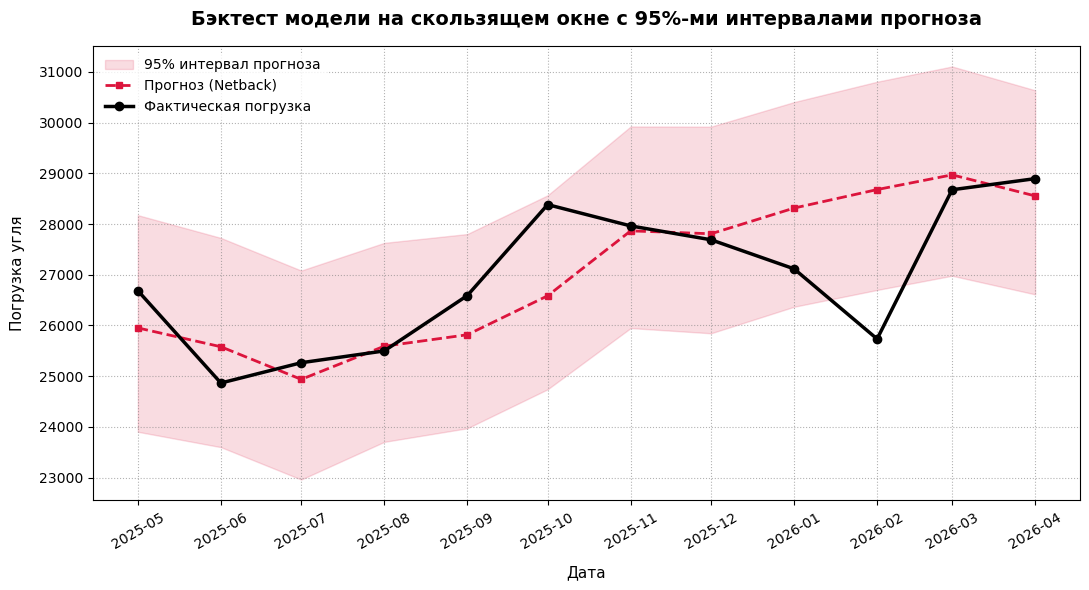

In [113]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_backtest_with_ci(formula, H=3, test_n=12):
    rows = []
    # Цикл по скользящему окну бэктеста
    for i in range(len(dn) - test_n, len(dn) - H + 1):
        m = smf.ols(formula, data=dn.iloc[:i]).fit()
        hist = dn["lcoal"].values.copy()
        
        for h in range(H):
            j = i + h
            x = dn.iloc[j].copy()
            x["lcoal_lag1"] = hist[j-1]
            
            # Получаем детальную структуру прогноза через get_prediction
            pred_obj = m.get_prediction(pd.DataFrame([x]))
            pred_frame = pred_obj.summary_frame(alpha=0.05) # alpha=0.05 означает 95% интервал
            
            yh = pred_frame['mean'].iloc[0]
            
            # Изучаем неопределенность: берем 'obs_ci' (prediction interval для конкретной точки),
            # так как мы хотим сравнить интервал с РЕАЛЬНЫМИ точками факта, а не просто оценить мат.ожидание.
            low_log = pred_frame['obs_ci_lower'].iloc[0]
            upp_log = pred_frame['obs_ci_upper'].iloc[0]
            
            # Возвращаем всё из логарифмов в уровни через np.exp()
            rows.append((dn.index[j], np.exp(dn["lcoal"].iloc[j]), np.exp(yh), np.exp(low_log), np.exp(upp_log)))
            hist[j] = yh
            
    r = pd.DataFrame(rows, columns=["date", "actual", "pred", "ci_lower", "ci_upper"])
    # Группируем по дате, усредняя пересекающиеся прогнозы (из-за шага H=3)
    return r.groupby("date").mean()

# Считаем данные для графика по нашей оптимальной модели с нетбэком
res_ci_df = get_backtest_with_ci("lcoal ~ lcoal_lag1 + netback_k + sin1 + cos1")

# === СТРОИМ СТИЛЬНЫЙ ГРАФИК ===
plt.figure(figsize=(11, 6), dpi=100)

# 1. Заливка доверительного интервала (95% Prediction Interval)
plt.fill_between(res_ci_df.index, res_ci_df['ci_lower'], res_ci_df['ci_upper'], 
                 color='crimson', alpha=0.15, label='95% интервал прогноза')

# 2. Линия прогноза модели
plt.plot(res_ci_df.index, res_ci_df['pred'], 
         color='crimson', linestyle='--', linewidth=2, marker='s', markersize=5, label='Прогноз (Netback)')

# 3. Линия фактических данных
plt.plot(res_ci_df.index, res_ci_df['actual'], 
         color='black', linestyle='-', linewidth=2.5, marker='o', markersize=6, label='Фактическая погрузка')

# Настройки оформления
plt.title('Бэктест модели на скользящем окне с 95%-ми интервалами прогноза', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=11, labelpad=10)
plt.ylabel('Погрузка угля', fontsize=11, labelpad=10)

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', shadow=False)
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Делаем подписи дат более аккуратными
plt.xticks(res_ci_df.index, [d.strftime('%Y-%m') for d in res_ci_df.index], rotation=30)
plt.tight_layout()

plt.show()

## 4.2 В попытках уменьшить стандартные ошибки добавим индекс отражающий экономическую активность Китая

In [114]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [118]:
pmi_raw = [50.0,50.3,50.4,49.0,49.3,50.1,49.2,49.0,49.8,49.4,49.3,49.7,49.5,49.0,50.5,50.2,
           49.1,50.1,50.3,50.1,49.8,49.1,49.4,49.5,49.5,50.4,50.8,49.1,49.2,49.0,49.4,49.5,50.2,49.7,49.3,49.0]
pmi = pd.Series(pmi_raw[::-1], index=pd.date_range(end="2026-05-01", periods=len(pmi_raw), freq="MS"), name="pmi")

d = dn.join(pmi, how="inner").copy()        # dn — твой netback-фрейм
d["netback_k"] = d["netback"] / 1000
d = d.dropna()

m = smf.ols("lcoal ~ lcoal_lag1 + netback_k + pmi + sin1", data=d).fit()
print(m.summary())

def bt(formula, data, H=3, test_n=12):
    rows = []
    for i in range(len(data)-test_n, len(data)-H+1):
        mm = smf.ols(formula, data=data.iloc[:i]).fit()
        hist = data["lcoal"].values.copy()
        for h in range(H):
            j = i+h; x = data.iloc[j].copy(); x["lcoal_lag1"] = hist[j-1]
            yh = float(mm.predict(pd.DataFrame([x])).iloc[0])
            rows.append((np.exp(data["lcoal"].iloc[j]), np.exp(yh))); hist[j] = yh
    r = pd.DataFrame(rows, columns=["a","p"]); e = r.a-r.p
    return (e.abs()/r.a).mean()*100, (e/r.a).mean()*100

for name, f in [("без pmi", "lcoal ~ lcoal_lag1 + netback_k + sin1"),
                ("с pmi ", "lcoal ~ lcoal_lag1 + netback_k + pmi + sin1")]:
    print(name, bt(f, d))

                            OLS Regression Results                            
Dep. Variable:                  lcoal   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     11.22
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.10e-05
Time:                        18:37:58   Log-Likelihood:                 70.396
No. Observations:                  35   AIC:                            -130.8
Df Residuals:                      30   BIC:                            -123.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1090      1.881      3.248      0.0

## 4.3 Результат показывает, что нет смысла использовать pmi. Таким образом, наиболее правильной с точки зрения MAPE будет использовать регрессию с лагом таргета, ценой угля, нетбэком и курсом рубля. 